Name: Kamble Ritesh

Roll no.:EN24207143

Batch: B

Subject: AI-NN

<h4>Implement Linear Regression using Batch Gradient Descent (BGD), Stochastic Gradient
Descent (SGD), and Mini-Batch Gradient Descent (MBGD).

1. Given a dataset of house prices (features: size, number of rooms), use Gradient
Descent to optimize model parameters.
2. Compare the convergence rates of BGD, SGD, and MBGD.</h4>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("Bengaluru_House_Data.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
df = df[['size', 'total_sqft', 'price']].dropna()

In [4]:
df

,size,total_sqft,price
0,2 BHK,1056,39.07
1,4 Bedroom,2600,120.00
2,3 BHK,1440,62.00
3,3 BHK,1521,95.00
4,2 BHK,1200,51.00
...,...,...,...
13315,5 Bedroom,3453,231.00
13316,4 BHK,3600,400.00
13317,2 BHK,1141,60.00
13318,4 BHK,4689,488.00


In [5]:
df.isnull().sum()

size          0
total_sqft    0
price         0
dtype: int64

In [6]:
df.dtypes

size           object
total_sqft     object
price         float64
dtype: object

In [7]:
df['size'] = df['size'].str.extract('(\d+)').astype(float)
def convert_sqft(x):
    try:
        if '-' in str(x):
            a, b = x.split('-')
            return (float(a) + float(b)) / 2
        return float(x)
    except:
        return np.nan

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)
df.dropna(inplace=True)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Sakshi Jadhav\AppData\Local\Temp\ipykernel_2972\3549839936.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['size'] = df['size'].str.extract('(\d+)').astype(float)


In [8]:
X = df[['total_sqft', 'size']].values
y = df['price'].values.reshape(-1, 1)

In [9]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

<h3>Batch Gradient Descent</h3>

BGD:  Weights=[0.3335792  0.20274054], Bias=0.0000


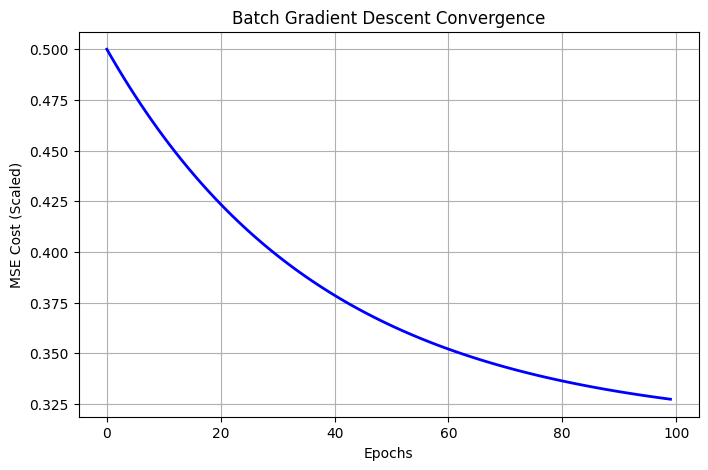

In [10]:
def batch_gradient_descent(X, y, lr=0.01, epochs=100):
    m, n = X.shape
    w = np.zeros((n, 1))
    b = 0
    cost_history = []

    for epoch in range(epochs):
        y_pred = np.dot(X, w) + b
        error = y_pred - y
        dw = (1/m) * np.dot(X.T, error)
        db = (1/m) * np.sum(error)
        w -= lr * dw
        b -= lr * db
        cost = (1/(2*m)) * np.sum(error**2)
        cost_history.append(cost)
    return w, b, cost_history

epochs=100
w_bgd, b_bgd, cost_bgd = batch_gradient_descent(X_scaled, y_scaled, lr=0.01, epochs=epochs)
print(f"BGD:  Weights={w_bgd.flatten()}, Bias={b_bgd:.4f}")
plt.figure(figsize=(8,5))
plt.plot(range(epochs), cost_bgd, color='blue', linewidth=2)
plt.title('Batch Gradient Descent Convergence')
plt.xlabel('Epochs')
plt.ylabel('MSE Cost (Scaled)')
plt.grid(True)
plt.show()

<h3>Stochastic Gradient Descent</h3>

SGD:  Weights=[0.40798984 0.27571329], Bias=-0.0195


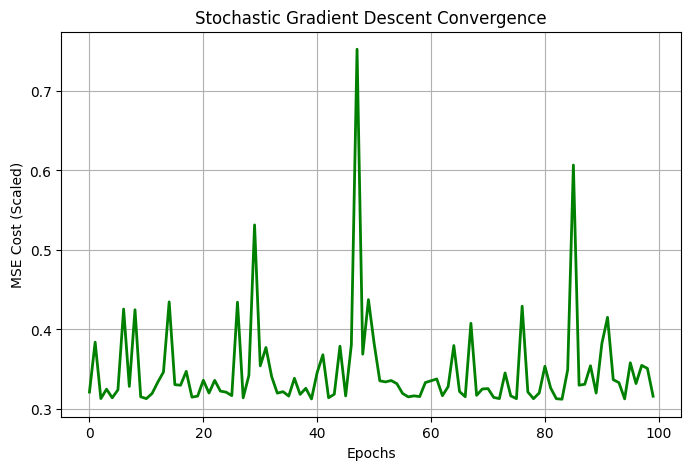

In [11]:
def stochastic_gradient_descent(X, y, lr=0.001, epochs=100):
    m, n = X.shape
    w = np.zeros((n, 1))
    b = 0
    cost_history = []

    for epoch in range(epochs):
        for i in range(m):
            rand_index = np.random.randint(m)
            xi = X[rand_index:rand_index+1]
            yi = y[rand_index:rand_index+1]
            
            y_pred = np.dot(xi, w) + b
            error = y_pred - yi
            dw = (1/1) * np.dot(xi.T, error)
            db = (1/1) * np.sum(error)
            w -= lr * dw
            b -= lr * db
        
        total_cost = (1/(2*m)) * np.sum((np.dot(X, w) + b - y)**2)
        cost_history.append(total_cost)
    return w, b, cost_history

epochs = 100
w_sgd, b_sgd, cost_sgd = stochastic_gradient_descent(X_scaled, y_scaled, lr=0.001, epochs=epochs)
print(f"SGD:  Weights={w_sgd.flatten()}, Bias={b_sgd:.4f}")
plt.figure(figsize=(8,5))
plt.plot(range(epochs), cost_sgd, color='green', linewidth=2)
plt.title('Stochastic Gradient Descent Convergence')
plt.xlabel('Epochs')
plt.ylabel('MSE Cost (Scaled)')
plt.grid(True)
plt.show()

<h3>Mini-Batch Gradient Descent</h3>

MBGD: Weights=[0.54016498 0.26664625], Bias=0.0060



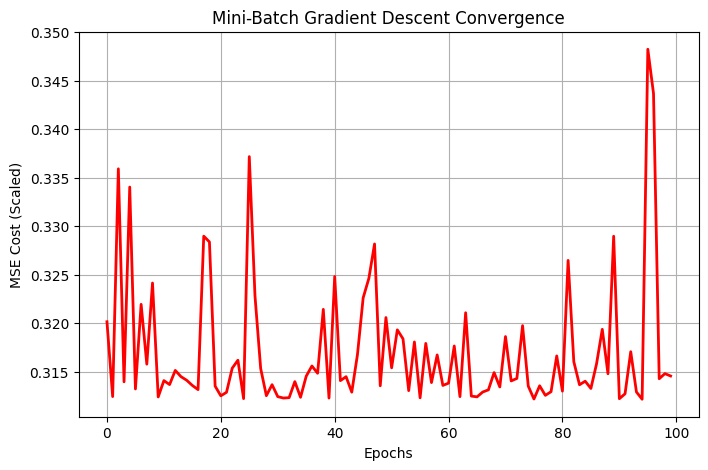

In [12]:
def mini_batch_gradient_descent(X, y, lr=0.01, epochs=100, batch_size=32):
    m, n = X.shape
    w = np.zeros((n, 1))
    b = 0
    cost_history = []

    for epoch in range(epochs):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            xi = X_shuffled[i:i+batch_size]
            yi = y_shuffled[i:i+batch_size]
            
            y_pred = np.dot(xi, w) + b
            error = y_pred - yi
            dw = (1/len(xi)) * np.dot(xi.T, error)
            db = (1/len(xi)) * np.sum(error)
            w -= lr * dw
            b -= lr * db
            
        total_cost = (1/(2*m)) * np.sum((np.dot(X, w) + b - y)**2)
        cost_history.append(total_cost)
    return w, b, cost_history

epochs = 100
w_mbgd, b_mbgd, cost_mbgd = mini_batch_gradient_descent(X_scaled, y_scaled, lr=0.01, epochs=epochs, batch_size=32)
print(f"MBGD: Weights={w_mbgd.flatten()}, Bias={b_mbgd:.4f}\n")
plt.figure(figsize=(8,5))
plt.plot(range(epochs), cost_mbgd, color='red', linewidth=2)
plt.title('Mini-Batch Gradient Descent Convergence')
plt.xlabel('Epochs')
plt.ylabel('MSE Cost (Scaled)')
plt.grid(True)
plt.show()

<h3>Convergence Comparison of Gradient Descent Algorithms</h3>

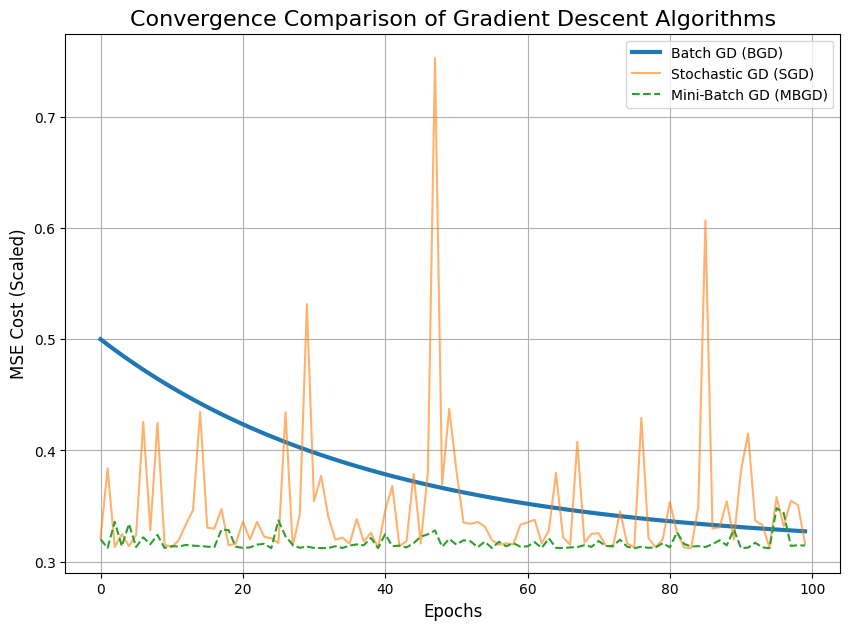

In [13]:
plt.figure(figsize=(10, 7))
plt.plot(range(epochs), cost_bgd, label='Batch GD (BGD)', linewidth=3)
plt.plot(range(epochs), cost_sgd, label='Stochastic GD (SGD)', alpha=0.6)
plt.plot(range(epochs), cost_mbgd, label='Mini-Batch GD (MBGD)', linestyle='--')
plt.title('Convergence Comparison of Gradient Descent Algorithms', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('MSE Cost (Scaled)', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()